In [67]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from scipy.interpolate import interp1d
import joblib

# Data inspection

In [68]:
ds = xr.open_dataset("windfield_z_100m.nc")

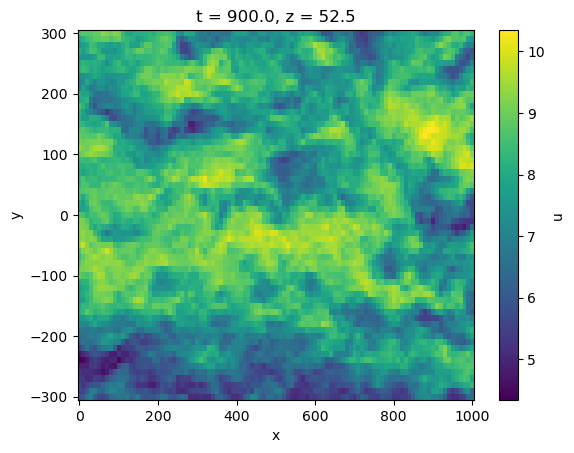

In [69]:
ds.isel(t=900,z=5)['u'].plot(x="x", y="y", cmap="viridis")

In [70]:
# Compute the mean profile over space for every single second
u_t = ds.u.mean(dim=['x', 'y'])  # Shape: (t, z)
v_t = ds.v.mean(dim=['x', 'y'])  # Shape: (t, z)
w_t = ds.w.mean(dim=['x', 'y'])  # Shape: (t, z)

u_x = ds.u.mean(dim=['t', 'y'])  # Shape: (x, z)
v_x = ds.v.mean(dim=['t', 'y'])  # Shape: (x, z)
w_x = ds.w.mean(dim=['t', 'y'])  # Shape: (x, z)

u_y = ds.u.mean(dim=['t', 'x'])  # Shape: (y, z)
v_y = ds.v.mean(dim=['t', 'x'])  # Shape: (y, z)
w_y = ds.w.mean(dim=['t', 'x'])  # Shape: (y, z)

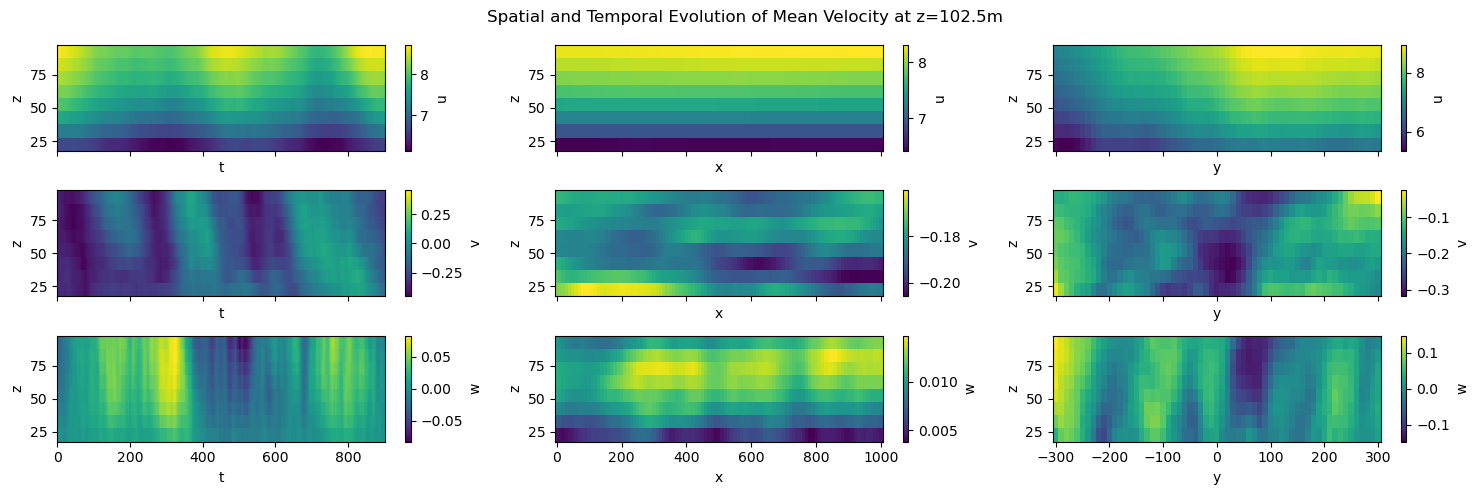

In [71]:
fig, ax = plt.subplots(3,3,figsize=(15, 5), sharex='col')
# Plot the evolution at your lowest grid point (2.5m) and highest grid point (102.5m)
u_t.isel(z=slice(2,10)).plot(x='t', y='z', label='U_xy(t) mean', ax=ax[0,0], cmap='viridis')
v_t.isel(z=slice(2,10)).plot(x='t', y='z', label='V_xy(t) mean', ax=ax[1,0], cmap='viridis')
w_t.isel(z=slice(2,10)).plot(x='t', y='z', label='W_xy(t) mean', ax=ax[2,0], cmap='viridis')

u_x.isel(z=slice(2,10)).plot(x='x', y='z', label='U_tz(x) mean', ax=ax[0,1], cmap='viridis')
v_x.isel(z=slice(2,10)).plot(x='x', y='z', label='V_tz(x) mean', ax=ax[1,1], cmap='viridis')
w_x.isel(z=slice(2,10)).plot(x='x', y='z', label='W_tz(x) mean', ax=ax[2,1], cmap='viridis')

u_y.isel(z=slice(2,10)).plot(x='y', y='z', label='U_tz(y) mean', ax=ax[0,2], cmap='viridis')
v_y.isel(z=slice(2,10)).plot(x='y', y='z', label='V_tz(y) mean', ax=ax[1,2], cmap='viridis')
w_y.isel(z=slice(2,10)).plot(x='y', y='z', label='W_tz(y) mean', ax=ax[2,2], cmap='viridis')


plt.suptitle('Spatial and Temporal Evolution of Mean Velocity at z=102.5m')
plt.tight_layout()
plt.show()

The flow does not seem to be stationary. Espescially in y where there seems to be a speed up later on.

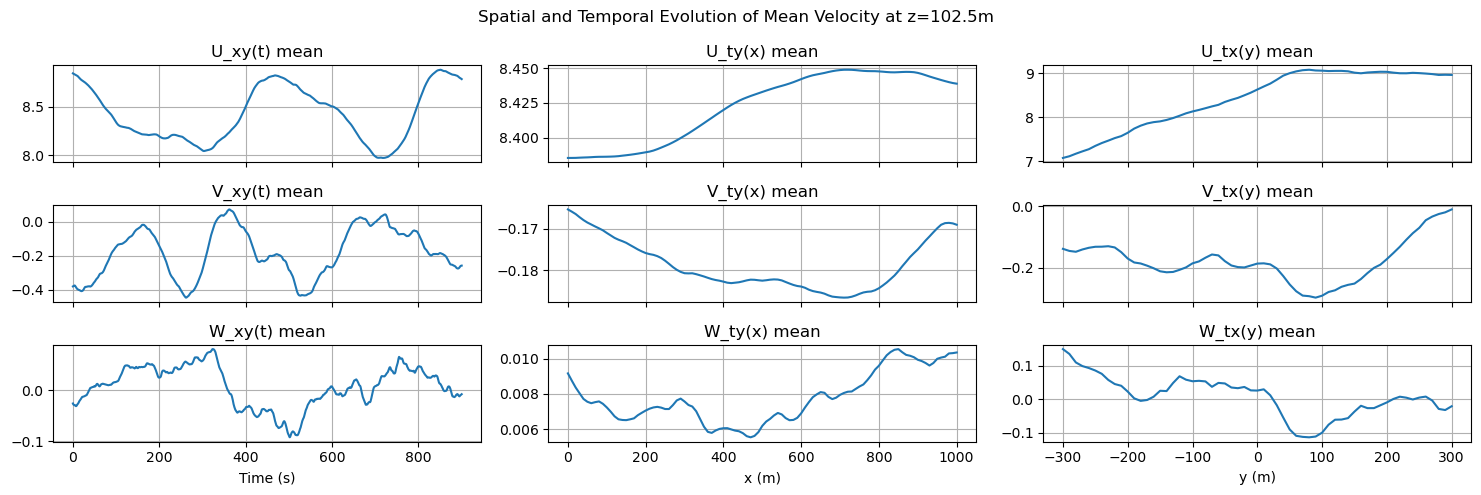

In [72]:
fig, ax = plt.subplots(3,3,figsize=(15, 5), sharex='col')
# Plot the evolution at your lowest grid point (2.5m) and highest grid point (102.5m)
ax[0,0].plot(ds.t, u_t.isel(z=-1), label='U_xy(t) mean')
ax[1,0].plot(ds.t, v_t.isel(z=-1), label='V_xy(t) mean')
ax[2,0].plot(ds.t, w_t.isel(z=-1), label='W_xy(t) mean')
ax[2,0].set_xlabel('Time (s)')

ax[0,1].plot(ds.x, u_x.isel(z=-1), label='U_ty(x) mean')
ax[1,1].plot(ds.x, v_x.isel(z=-1), label='V_ty(x) mean')
ax[2,1].plot(ds.x, w_x.isel(z=-1), label='W_ty(x) mean')
ax[2,1].set_xlabel('x (m)')

ax[0,2].plot(ds.y, u_y.isel(z=-1), label='U_tx(y) mean')
ax[1,2].plot(ds.y, v_y.isel(z=-1), label='V_tx(y) mean')
ax[2,2].plot(ds.y, w_y.isel(z=-1), label='W_tx(y) mean')
ax[2,2].set_xlabel('y (m)')

for i in range(3):
    for j in range(3):
        ax[i,j].set_title(ax[i,j].legend().get_texts()[0].get_text())
        ax[i,j].legend().remove()
        ax[i,j].grid(True)

plt.suptitle('Spatial and Temporal Evolution of Mean Velocity at z=102.5m')
plt.tight_layout()
plt.show()

Here it is clearly seen how the mean velocity in y increases

# Creation of POD library

In [73]:
# Create a visualization of the energy distribution of the pod modes 
# and find the number of modes required to capture a certain percentage of the energy.
def plot_pod_energy(S, threshold=0.8):
    # Calculate Eigenvalues (Energy)
    lambdas = S**2
    
    # Calculate Individual and Cumulative Energy Fraction
    energy_fraction = lambdas / np.sum(lambdas)
    cumulative_energy = np.cumsum(energy_fraction)
    
    # Find the index where we cross the threshold
    n_required = np.argmax(cumulative_energy >= threshold) + 1
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Individual Energy (Bar Chart)
    ax1.bar(range(1, len(energy_fraction) + 1), energy_fraction, alpha=0.6, color='g', label='Individual Mode Energy')
    ax1.set_xlabel('Mode Number')
    ax1.set_ylabel('Energy Fraction', color='g')
    ax1.tick_params(axis='y', labelcolor='g')

    # Cumulative Energy (Step/Line Chart)
    ax2 = ax1.twinx()
    ax2.step(range(1, len(cumulative_energy) + 1), cumulative_energy, where='mid', color='b', label='Cumulative Energy')
    ax2.axhline(y=threshold, color='r', linestyle='--', label=f'{int(threshold*100)}% Threshold')
    ax2.axvline(x=n_required, color='r', linestyle=':')
    ax2.set_ylabel('Cumulative Energy Fraction', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    plt.title(f'POD Energy Spectrum (Modes for {int(threshold*100)}% Energy: {n_required})')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()
    
    return n_required


In [74]:
# Main function to create the POD library from the LES dataset
def create_pod_library(ds, threshold=0.9):
    """
    Decomposes LES wind data into a unscaled POD modes.
    
    Returns:
        A dictionary containing callable interpolators for modes and coefficients,
        plus eigenvalues for TKE scaling in the solver.
    """
    # Prepare Dimensions
    n_t, n_x, n_y, n_z = len(ds.t), len(ds.x), len(ds.y), len(ds.z)
    z_coords = ds.z.values

    # Calculate the mean profile
    u_mean = ds.u.mean(dim=['t', 'x', 'y'])
    v_mean = ds.v.mean(dim=['t', 'x', 'y'])
    w_mean = ds.w.mean(dim=['t', 'x', 'y'])

    # Center the data
    u_prime = (ds.u - u_mean).stack(samples=('t', 'x', 'y')).values
    v_prime = (ds.v - v_mean).stack(samples=('t', 'x', 'y')).values
    w_prime = (ds.w - w_mean).stack(samples=('t', 'x', 'y')).values

    
    # Combined snapshot matrix X: (3*z, samples)
    X = np.vstack([u_prime, v_prime, w_prime])

    # SVD -> Compute the singular value decomposition
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    # Determine number of modes based on energy threshold
    n_modes = plot_pod_energy(S, threshold=threshold)

    # Scale and Reshape Spatial Modes (U/Phi)
    # Explicitly split components from U: (3*z, n_modes)
    # Rows 0:n_z -> u component, n_z:2*n_z -> v component, 2*n_z:3*n_z -> w component
    U_modes = U[0:n_z, :n_modes]           # (n_z, n_modes)
    V_modes = U[n_z:2*n_z, :n_modes]      # (n_z, n_modes)
    W_modes = U[2*n_z:3*n_z, :n_modes]    # (n_z, n_modes)
    
    # Stack components into modes_array: (n_modes, n_z, 3)
    # This represents the vertical 'shape' of the gusts for each component
    modes_array = np.stack([U_modes.T, V_modes.T, W_modes.T], axis=2)  # (n_modes, n_z, 3)

    # Scale and Reshape Temporal/Spatial Coefficients (a)
    # multiply by singular values for proper scaling of the modes
    coeffs = Vh[:n_modes, :] * S[:n_modes, np.newaxis]  # (n_modes, samples)
    
    # Create interpolation function for modes
    modes_func = interp1d(z_coords, modes_array, axis=1, bounds_error=False, fill_value="extrapolate")

    # Calculate Eigenvalues (Energy) for TKE scaling
    eigenvalues = S**2 / (n_t*n_x*n_y - 1)
    total_energy = np.sum(eigenvalues)
    gamma = eigenvalues[:n_modes] / total_energy

    # Package of the POD Library for external use
    pod_lib = {
        'modes': modes_func,           # Callable z -> modes, direction
        'gamma': gamma,                # TKE fraction for each mode
        'z_coords': z_coords
    }

    # Package of the Statistical Library for analysis or reconstruction
    stat_lib = {
        'coeffs': coeffs,              # Temporal coefficients for reconstruction
        'eigenvalues': eigenvalues,     # Energy of each mode for scaling
        'samples': n_t*n_x*n_y             # Original sample indices for reference
    }
    
    # Save the libraries for future use
    joblib.dump(pod_lib, 'pod_library.joblib', compress=3)
    joblib.dump(stat_lib, 'stat_library.joblib', compress=3)
    return pod_lib, stat_lib

In [75]:
# avoid running the SVD if the data is already processed and saved in a library
try:
    pod_lib = joblib.load('pod_library.joblib')
    stat_lib = joblib.load('stat_library.joblib')
    print("POD and stat library loaded from file.")
except FileNotFoundError:
    print("File not found. Creating new POD library.")
    # chosen slice at y=200 to capture the developed flow as seen in the inspection
    pod_lib, stat_lib = create_pod_library(ds.sel(y=slice(200, 200)), threshold=0.9) # 40 mb

POD and stat library loaded from file.


# Analysis

Let us take a look at the 9 first modes

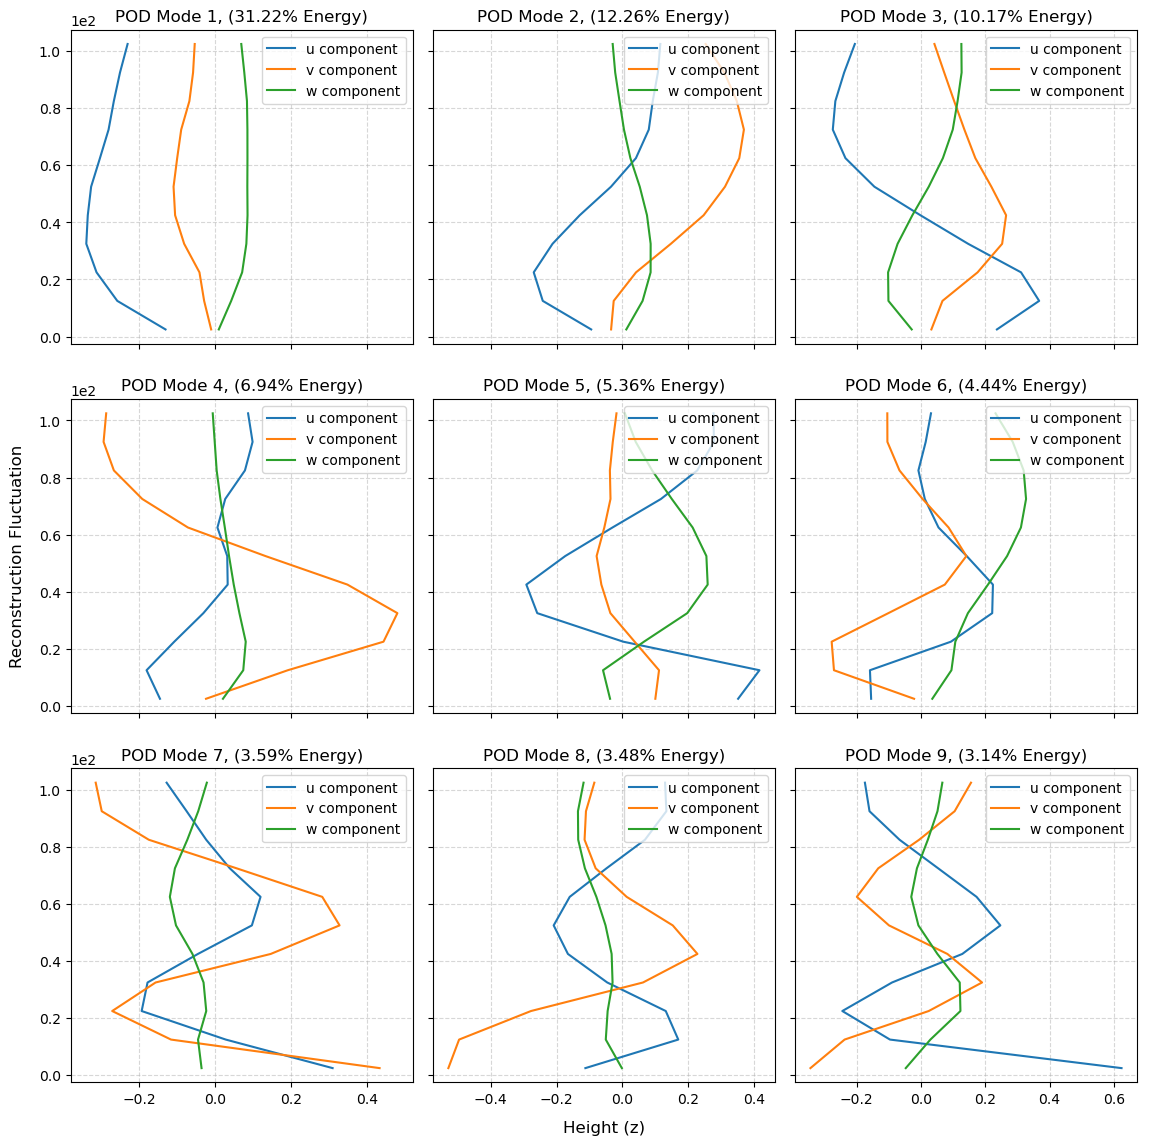

In [76]:
# import the libraries and visualize the first 9 modes with their energy contribution
phi = pod_lib['modes']
z_coords = pod_lib['z_coords']
eig = stat_lib['eigenvalues']
dis = eig / np.sum(eig)
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex='col', sharey=True)

for m in range(9):
    for i, comp in enumerate(['u', 'v', 'w']):
        ax[m//3, m%3].plot(phi(z_coords)[m, :, i], z_coords, label=f'{comp} component')
        ax[m//3, m%3].set_title(f'POD Mode {m+1}, ({dis[m]*100:.2f}% Energy)')
        ax[m//3, m%3].grid(True, which='both', linestyle='--', alpha=0.5)
        ax[m//3, m%3].legend(loc='upper right')

        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Height (z)", labelpad=10, fontsize=12)
plt.ylabel("Reconstruction Fluctuation", labelpad=10, fontsize=12)

plt.tight_layout()
plt.show()

First mode seems to primarily be a "drift" mode that corrects a spatial or temporal change in average velocity.

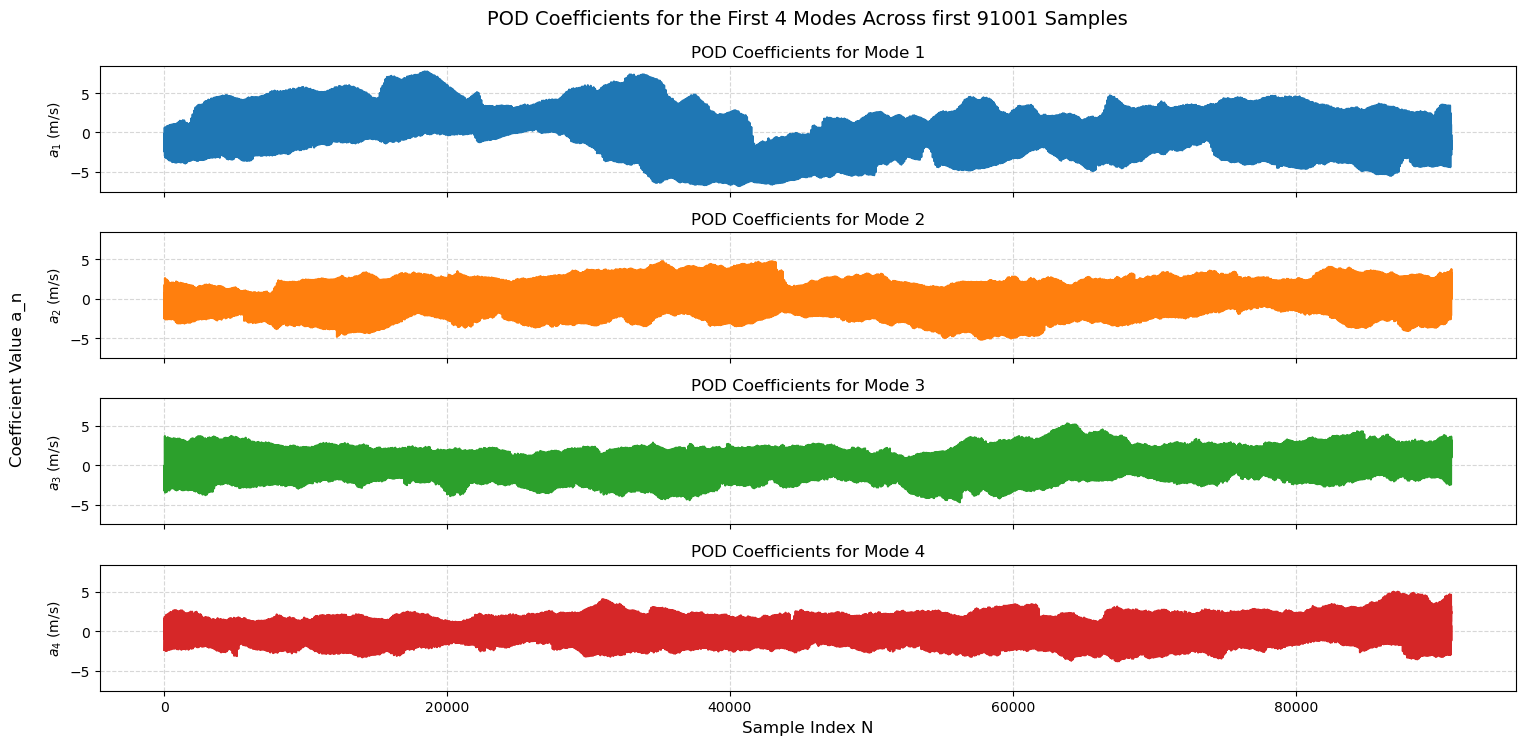

In [77]:
a = stat_lib['coeffs']

fig, ax = plt.subplots(4,1,figsize=(16, 8), sharex=True, sharey=True)

plot_start = 0 # len(samples) // 2  # Start plotting from the middle of the sample range
plot_n =  a.shape[1] # 400
for m in range(0,4,1): # Loop over the first 5 modes
    ax[m].plot(range(plot_start, plot_start + plot_n, 1), a[m][plot_start:plot_start + plot_n], color=f'C{m}')
    ax[m].set_title(f'POD Coefficients for Mode {m+1}')
    ax[m].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[m].set_ylabel(fr'$a_{m+1}$ (m/s)')

# add a big invisible axis for the overall title and labels
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.title(f'POD Coefficients for the First 4 Modes Across first {plot_n} Samples', fontsize=14, pad=30)
plt.xlabel("Sample Index N", fontsize=12)
plt.ylabel("Coefficient Value a_n", labelpad=30, fontsize=12)
plt.tight_layout()
plt.show()

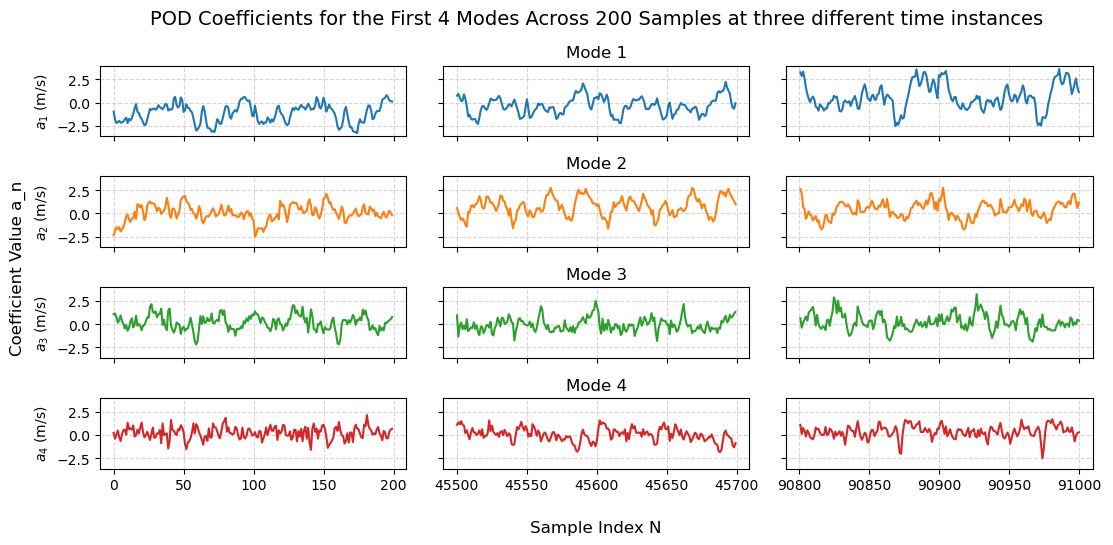

In [78]:
a = stat_lib['coeffs']

fig, ax = plt.subplots(4,3,figsize=(12, 6), sharey=True, sharex='col')

n = a.shape[1]
plot_n = 200
shifts = [0, n//2, n-plot_n] # Shift starting points for each mode to visualize different parts of the sample space
for m, shift in enumerate(shifts*4): # Loop over the first 5 modes
    ax[m//3, m%3].plot(range(shift, shift + plot_n, 1), a[m][shift:shift + plot_n], color=f'C{m//3}')
    ax[m//3, 1].set_title(f'Mode {m//3+1}')
    ax[m//3, m%3].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[m//3, 0].set_ylabel(fr'$a_{m//3+1}$ (m/s)')

# add a big invisible axis for the overall title and labels
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.title(f'POD Coefficients for the First 4 Modes Across {plot_n} Samples at three different time instances', fontsize=14, pad=30)
plt.xlabel("Sample Index N", labelpad=20, fontsize=12)
plt.ylabel("Coefficient Value a_n", labelpad=30, fontsize=12)
plt.tight_layout()
plt.show()

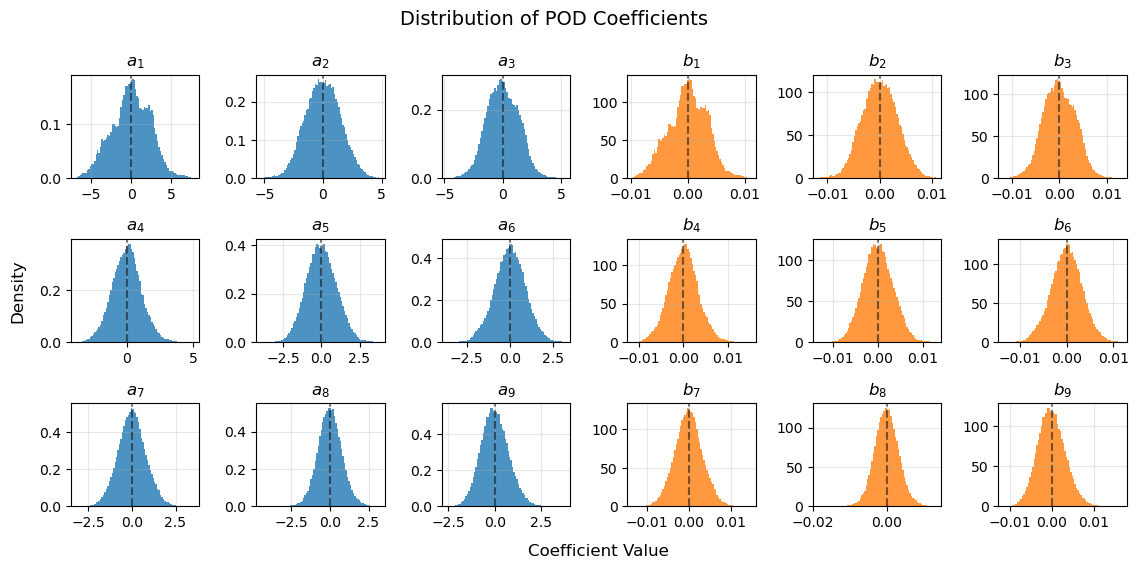

In [79]:
fig, axs = plt.subplots(3, 6, figsize=(12, 6), sharex=False, sharey=False)

S = np.sqrt(stat_lib['eigenvalues'] * (stat_lib['samples'] - 1))

# 2. Get the number of saved modes from your coefficients shape
n_modes = stat_lib['coeffs'].shape[0]

# 3. Reconstruct V^T (up to the number of kept modes)
# We divide each row of coefficients by its corresponding singular value
Vh = stat_lib['coeffs'] / S[:n_modes, np.newaxis]

for m in range(9):

    data = a[m]
    data_unscaled = Vh[m]  # Unscaled coefficients for comparison
    
    # Plot fordelingen
    axs[m//3, m%3].hist(data, bins=80, density=True, alpha=0.8)
    axs[m//3, m%3].axvline(0, color='black', linestyle='--', alpha=0.5) # center at 0
    axs[m//3, m%3].set_title(f'$a_{m+1}$')
    axs[m//3, m%3].grid(alpha=0.3)

    axs[m//3, m%3+3].hist(data_unscaled, bins=80, density=True, alpha=0.8, color='tab:orange')
    axs[m//3, m%3+3].axvline(0, color='black', linestyle='--', alpha=0.5) # center at 0
    axs[m//3, m%3+3].set_title(f'$b_{m+1}$')
    axs[m//3, m%3+3].grid(alpha=0.3)
#plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
fig.suptitle('Distribution of POD Coefficients', fontsize=14)
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Coefficient Value", labelpad=10, fontsize=12)
plt.ylabel("Density", labelpad=10, fontsize=12)
plt.tight_layout()
plt.show()

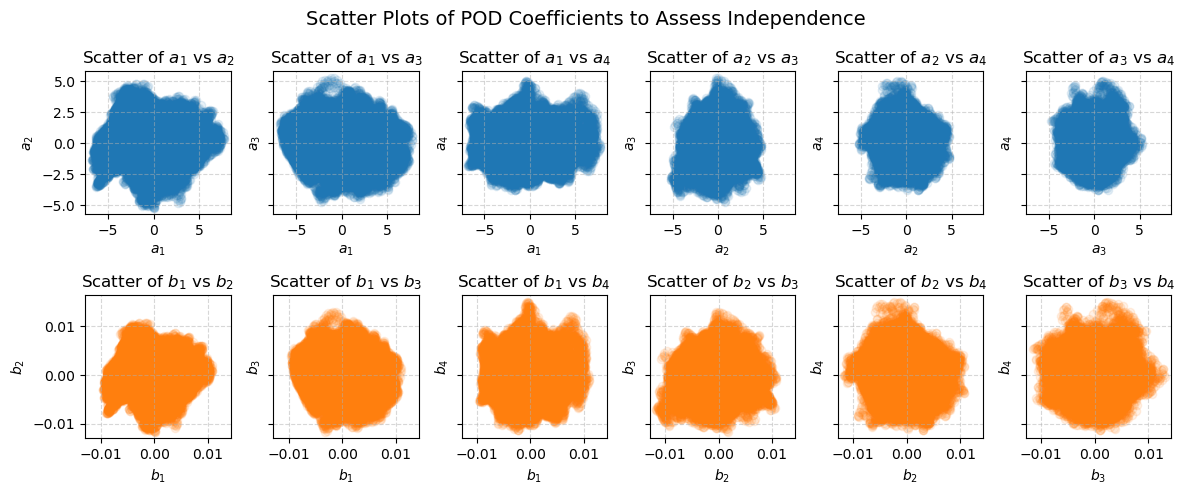

In [80]:
# check indepence of the coefficients by plotting them against each other in a scatter plot
fig, ax = plt.subplots(2,6, figsize=(12,5), sharey='row', sharex='row')

# make 3x3 plot with a1 vs a2, a1 vs a3, a2 vs a3 etc
for i, (j, k) in enumerate([(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]):
    
    ax[0, i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[0, i].scatter(a[j], a[k], alpha=0.1)
    ax[0, i].set_xlabel(f'$a_{j+1}$')
    ax[0, i].set_ylabel(f'$a_{k+1}$')
    ax[0, i].set_title(f'Scatter of $a_{j+1}$ vs $a_{k+1}$')

    ax[1, i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[1, i].scatter(Vh[j], Vh[k], alpha=0.1, color='tab:orange')
    ax[1, i].set_xlabel(f'$b_{j+1}$')
    ax[1, i].set_ylabel(f'$b_{k+1}$')
    ax[1, i].set_title(f'Scatter of $b_{j+1}$ vs $b_{k+1}$')

plt.suptitle('Scatter Plots of POD Coefficients to Assess Independence', fontsize=14)
plt.tight_layout()
plt.show()

Here they seem quite independent. There is no clear trend of dependency between the different modes. 

**$a_2$ vs $a_4$ does look a bit like a pentagon

# Reconstruction Example

In [81]:
def plot_scaled_pod(pod_lib, n_modes, wind: WindField, ax=None):
    tke_rans = wind.ds.tke.values
    z_coords = wind.ds.z.values

    phi = pod_lib['modes']
    gamma = pod_lib['gamma'][:n_modes]

    # Draw standard normal random variables (variance = 1.0) for each mode.
    # This keeps the coefficients pristine until we apply the exact target scaling.
    ran = np.random.normal(loc=0.0, scale=1.0, size=n_modes)

    prime = np.zeros((3, len(tke_rans)))

    for i, z in enumerate(z_coords):
        # Compute the exact physical standard deviation vector for all modes at this height
        # Shape: (n_modes,)
        sigma_target = np.sqrt(2.0 * tke_rans[i] * gamma) # tke at z for n modes
        
        # Scale the random coefficients to their physical target (N(0, sigma_target^2))
        # Shape: (n_modes,)
        a_local = ran * sigma_target
        
        # Reconstruct the velocity components smoothly
        if n_modes == 1:
            raw_prime = a_local[0] * phi(z)[0] # single mode is just a scalar times the mode shape
        else:
            raw_prime = a_local @ phi(z)[:n_modes] # multile modes are a linear combination of the mode shapes
            
        prime[:, i] = raw_prime
        
    if ax is None:
        ax = plt.gca()

    u = wind.ds.U.values + prime[0]
    v = wind.ds.V.values + prime[1]
    w = wind.ds.W.values + prime[2]

    ax.plot(u, wind.ds.z.values, label='U with POD Fluctuations for {0} modes'.format(n_modes))
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Height (m)')

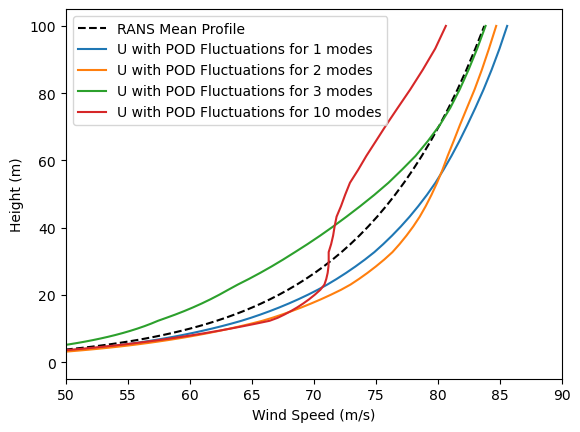

In [82]:
w = WindField(U_ref=60, z_ref=10)
plt.plot(w.ds.U.values, w.ds.z.values, label='RANS Mean Profile', color='k', linestyle='--')
plot_scaled_pod(pod_lib, n_modes=1, wind=w)
plot_scaled_pod(pod_lib, n_modes=2, wind=w)
plot_scaled_pod(pod_lib, n_modes=3, wind=w)
plot_scaled_pod(pod_lib, n_modes=10, wind=w)
plt.xlim(50,90)
plt.legend()